# For all rt files

Total Files:  ['sac_rt_scr-0.0024444_mopt-0.14', 'sac_rt_scr-0.00288889_mopt-0.14', 'sac_rt_scr-0.002_mopt-0.14', 'sac_rt_scr-0.0033333_mopt-0.14', 'sac_rt_scr-0.00377778_mopt-0.14', 'sac_rt_scr-0.00422222_mopt-0.14', 'sac_rt_scr-0.00466667_mopt-0.14', 'sac_rt_scr-0.00511111_mopt-0.14', 'sac_rt_scr-0.00555556_mopt-0.14', 'sac_rt_scr-0.006_mopt-0.14']
Working on file: 1/10


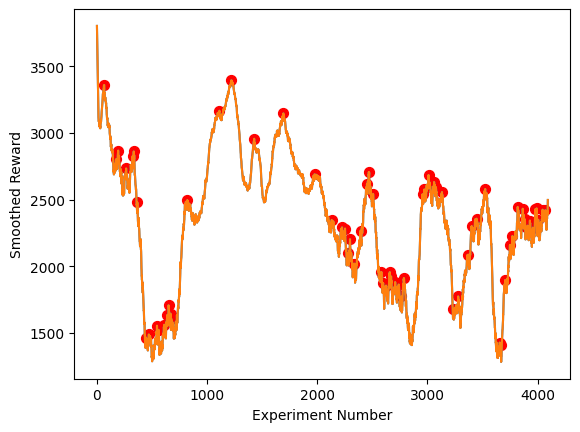

{'scr': 0.0024444, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(72.0), 'ea_peak': np.float64(2.161562855190063), 'rew_peak_exp': np.float64(66.0), 'reward_peak': np.float64(3360.2)}
Working on file: 2/10


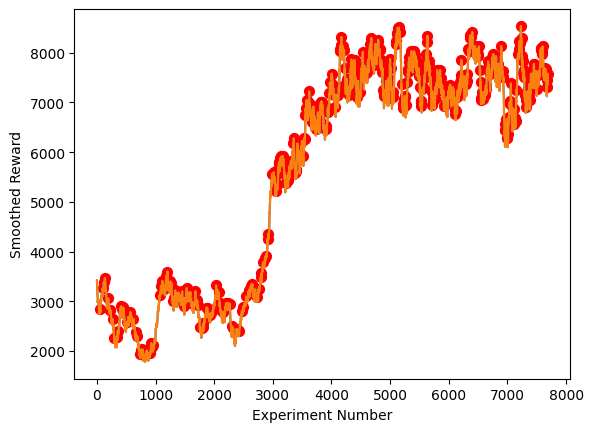

{'scr': 0.00288889, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(138.0), 'ea_peak': np.float64(1.9588872870886753), 'rew_peak_exp': np.float64(51.0), 'reward_peak': np.float64(2838.9)}
Working on file: 3/10


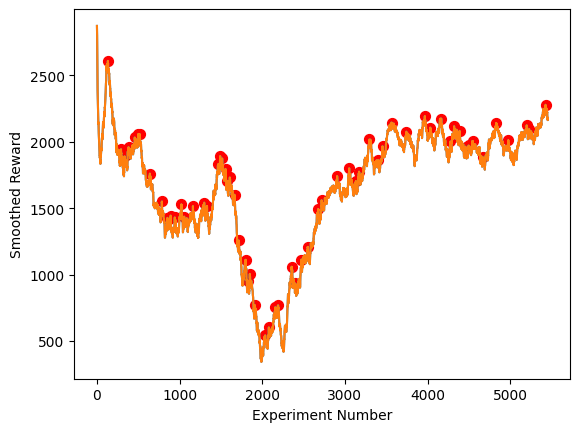

{'scr': 0.002, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(121.0), 'ea_peak': np.float64(1.8543753659618358), 'rew_peak_exp': np.float64(133.0), 'reward_peak': np.float64(2610.0)}
Working on file: 4/10


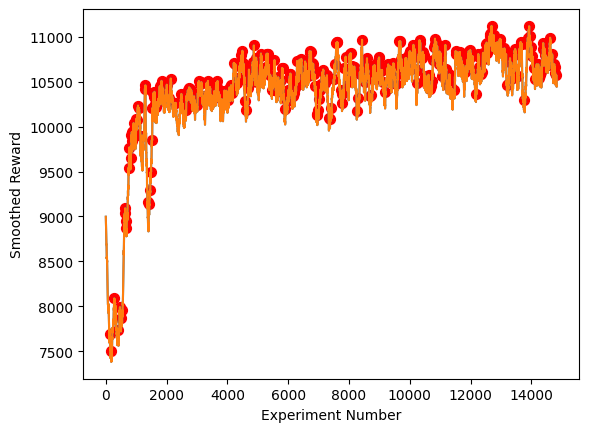

{'scr': 0.0033333, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(282.0), 'ea_peak': np.float64(3.181101122236737), 'rew_peak_exp': np.float64(132.0), 'reward_peak': np.float64(7689.8)}
Working on file: 5/10


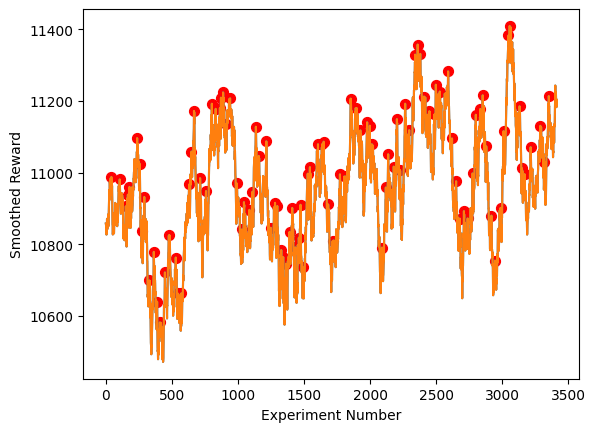

{'scr': 0.00377778, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(154.0), 'ea_peak': np.float64(3.50706283209348), 'rew_peak_exp': np.float64(43.0), 'reward_peak': np.float64(10987.9)}
Working on file: 6/10


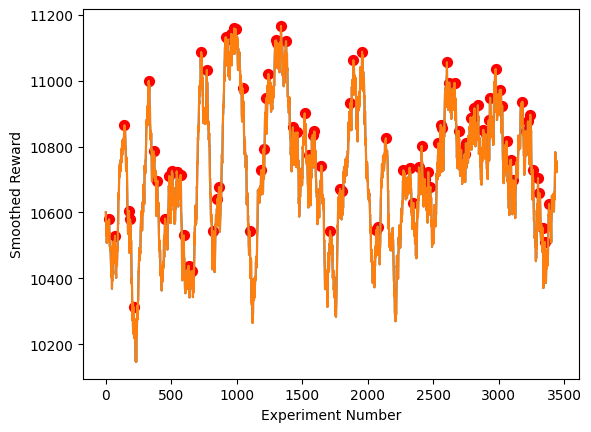

{'scr': 0.00422222, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(179.0), 'ea_peak': np.float64(3.304185157136392), 'rew_peak_exp': np.float64(26.0), 'reward_peak': np.float64(10579.2)}
Working on file: 7/10


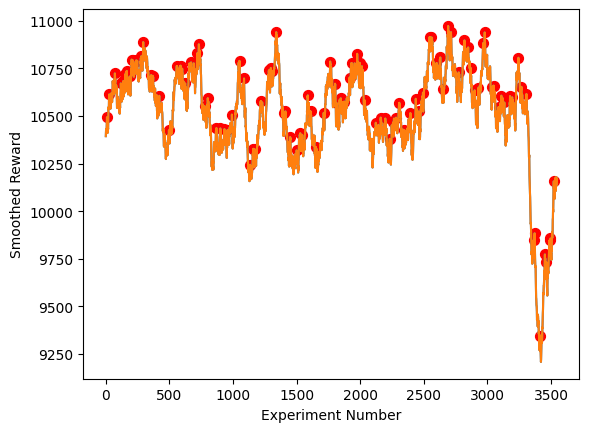

{'scr': 0.00466667, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(42.0), 'ea_peak': np.float64(3.123024385242285), 'rew_peak_exp': np.float64(10.0), 'reward_peak': np.float64(10494.099999999999)}
Working on file: 8/10


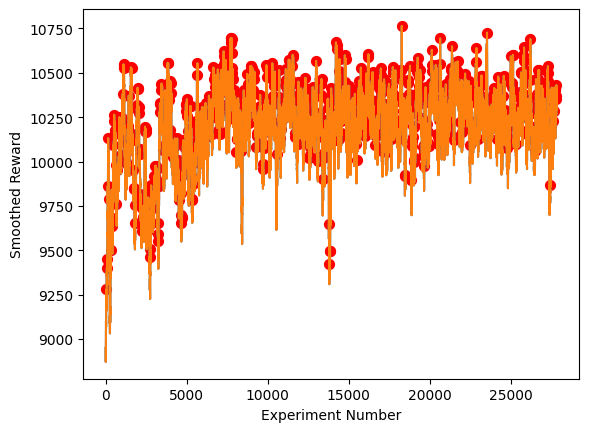

{'scr': 0.00511111, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(110.0), 'ea_peak': np.float64(2.3676488804060756), 'rew_peak_exp': np.float64(44.0), 'reward_peak': np.float64(9280.200000000003)}
Working on file: 9/10


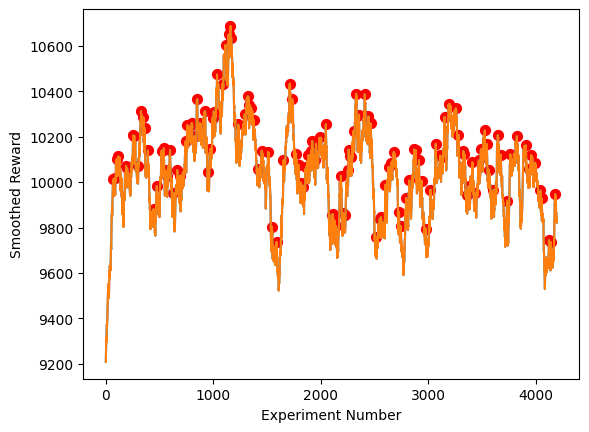

{'scr': 0.00555556, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(145.0), 'ea_peak': np.float64(2.7691087285871645), 'rew_peak_exp': np.float64(69.0), 'reward_peak': np.float64(10012.3)}
Working on file: 10/10


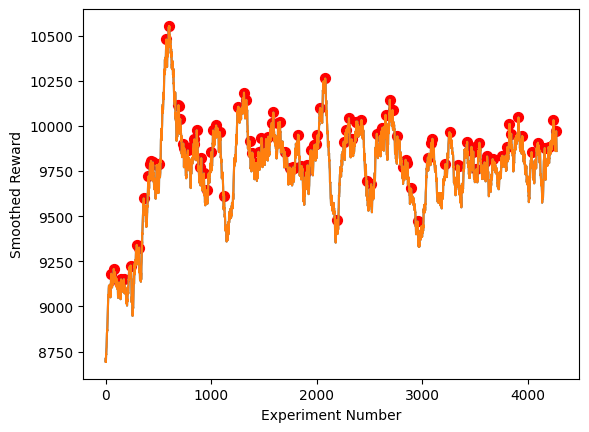

{'scr': 0.006, 'mue_opt': 0.14, 'ea_peak_exp': np.float64(74.0), 'ea_peak': np.float64(2.534072945135266), 'rew_peak_exp': np.float64(54.0), 'reward_peak': np.float64(9181.099999999999)}


In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import re

def extract_scr_mopt(filename):
    pattern = r"scr-([-+]?\d*\.?\d+)_mopt-([-+]?\d*\.?\d+)"
    match = re.search(pattern, filename)
    
    if match:
        scr_value = float(match.group(1))
        mopt_value = float(match.group(2))
        return scr_value, mopt_value
    else:
        return None, None  # Return None if pattern is not found

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

ri_files = sorted([file for file in os.listdir('experiments') if 'rt' in file])
print("Total Files: ", ri_files)
data_df = []
file_num = 1
for file in ri_files:
    rewards = []
    print(f"Working on file: {file_num}/{len(ri_files)}")
    eval_data_path = os.path.join('experiments',file,'training_data.csv')
    scr, muopt = extract_scr_mopt(file)
    df = pd.read_csv(eval_data_path)
    enzyme_activitys = []
    experiment_numbers = []
    index_value = df.index[df['timestep'] == 0].tolist()

    for i in range(len(index_value)):
        if i != len(index_value) - 1:
            start_index = index_value[i]
            end_index = index_value[i + 1] - 1
            enzyme_activity = df['enzyme_activity'].loc[end_index]
            exp_num = df['experiment_number'].loc[end_index]
            enzyme_activitys.append(enzyme_activity)
            experiment_numbers.append(exp_num)

            subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
            reward_sum = subset_df['reward'].sum()
            rewards.append(reward_sum)

    
    smoothed_activities = moving_average(enzyme_activitys, window_size=50)
    smoothed_rewards = moving_average(rewards, window_size=100)

    ea_peaks, _ = find_peaks(smoothed_activities, prominence=0.1)
    reward_peaks, _ = find_peaks(smoothed_rewards, prominence=70)

    ea_first_peak = ea_peaks[0]
    ea_first_peak_exp = experiment_numbers[ea_first_peak]
    ea_first_peak = smoothed_activities[ea_first_peak]

    #print("This is peak at 0: ", reward_peaks[0])
    reward_first_peak = reward_peaks[0]
    rewards_first_peak_exp = experiment_numbers[reward_first_peak]
    reward_first_peak = smoothed_rewards[reward_first_peak]

    plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards)
    plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label="Smoothed Rewards")

    # Ensure peaks exist before plotting
    if len(reward_peaks) > 0:
        for peak in reward_peaks:
            plt.scatter(experiment_numbers[peak], smoothed_rewards[peak], s=50, color='red', label="Peak Point")

    plt.xlabel("Experiment Number")
    plt.ylabel("Smoothed Reward")
    plt.show()

    data_df.append({
        'scr': scr,
        'mue_opt' : muopt,
        'ea_peak_exp' : ea_first_peak_exp,
        'ea_peak' : ea_first_peak,
        'rew_peak_exp' : rewards_first_peak_exp,
        'reward_peak' : reward_first_peak
    })
    file_num += 1
    print({
        'scr': scr,
        'mue_opt' : muopt,
        'ea_peak_exp' : ea_first_peak_exp,
        'ea_peak' : ea_first_peak,
        'rew_peak_exp' : rewards_first_peak_exp,
        'reward_peak' : reward_first_peak
    })


df = pd.DataFrame(data_df)

df.to_csv("peaks_data.csv")

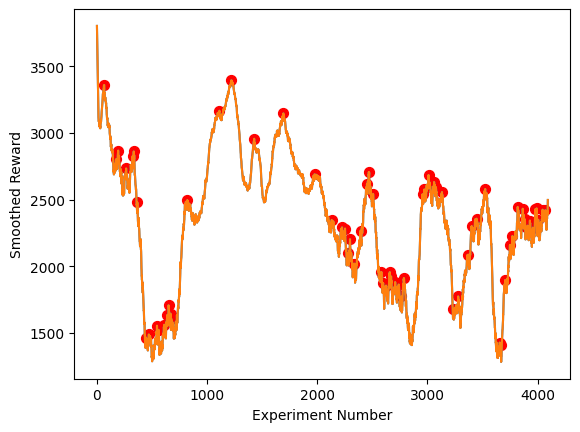

In [ ]:
smoothed_activities = moving_average(enzyme_activitys, window_size=50)
smoothed_rewards = moving_average(rewards, window_size=100)

ea_peaks, _ = find_peaks(smoothed_activities, prominence=0.1)
reward_peaks, _ = find_peaks(smoothed_rewards, prominence=70)

ea_first_peak = ea_peaks[0]
ea_first_peak_exp = experiment_numbers[ea_first_peak]
ea_first_peak = smoothed_activities[ea_first_peak]

#print("This is peak at 0: ", reward_peaks[0])
reward_first_peak = reward_peaks[0]
rewards_first_peak_exp = experiment_numbers[reward_first_peak]
reward_first_peak = smoothed_rewards[reward_first_peak]

plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards)
plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label="Smoothed Rewards")

# Ensure peaks exist before plotting
if len(reward_peaks) > 0:
    for peak in reward_peaks:
        plt.scatter(experiment_numbers[peak], smoothed_rewards[peak], s=50, color='red', label="Peak Point")

plt.xlabel("Experiment Number")
plt.ylabel("Smoothed Reward")
plt.show()

#     data_df.append({
#         'scr': scr,
#         'mue_opt' : muopt,
#         'ea_peak_exp' : ea_first_peak_exp,
#         'ea_peak' : ea_first_peak,
#         'rew_peak_exp' : rewards_first_peak_exp,
#         'reward_peak' : reward_first_peak
#     })
#     file_num += 1
#     print({
#         'scr': scr,
#         'mue_opt' : muopt,
#         'ea_peak_exp' : ea_first_peak_exp,
#         'ea_peak' : ea_first_peak,
#         'rew_peak_exp' : rewards_first_peak_exp,
#         'reward_peak' : reward_first_peak
#     })


# df = pd.DataFrame(data_df)

# df.to_csv("peaks_data.csv")

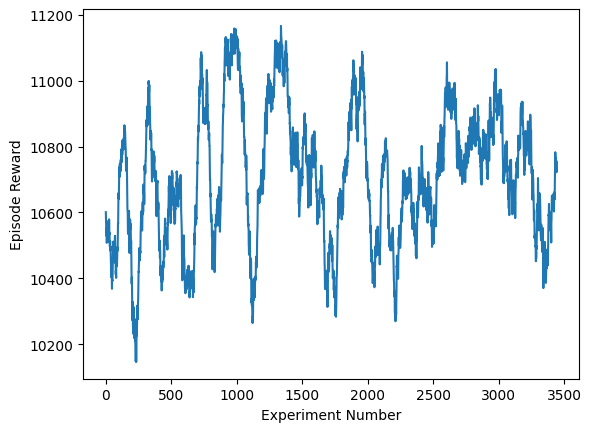

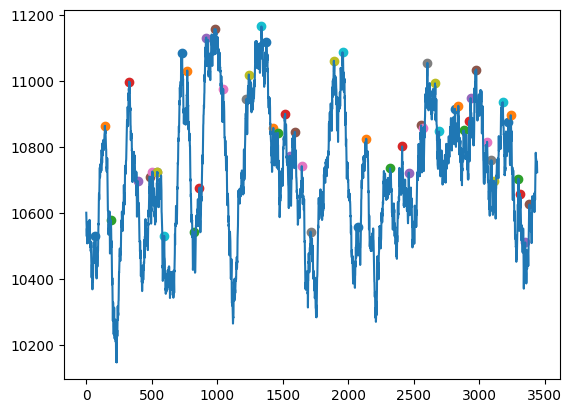

Text(0, 0.5, 'Episode Reward')

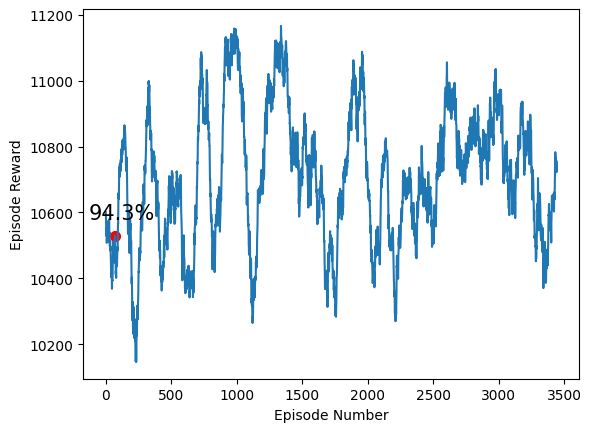

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

sac_experiment_name = 'sac_rt_scr-0.00422222_mopt-0.14'

sac_eval_data_path = os.path.join('experiments', sac_experiment_name, 'training_data.csv')

df = pd.read_csv(sac_eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

# Apply moving average smoothing only to rewards
smoothed_rewards = moving_average(rewards, window_size=100)

# Adjust max reward index for the smoothed values
max_reward_index = np.argmax(smoothed_rewards)

#plt.scatter(experiment_numbers[max_reward_index], smoothed_rewards[max_reward_index], color='blue', marker='o', s=50, zorder=3)
plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label='SAC test data (Smoothed)')
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")
plt.show()

from scipy.signal import find_peaks


last_n_percent = 10
last_n_percent_len = int(len(smoothed_rewards) * last_n_percent/100)
last_n_data = smoothed_rewards[-last_n_percent_len:]
average_max_reward = sum(last_n_data)/len(last_n_data)
max_reward = max(smoothed_rewards)

percentage = (average_max_reward/max_reward) * 100
reward_peaks, _ = find_peaks(smoothed_rewards, prominence=100)

plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards)

for peak in reward_peaks:
    plt.scatter(experiment_numbers[peak], smoothed_rewards[peak])

plt.show()

first_peak_reward = smoothed_rewards[reward_peaks[0]]

peak_percentage = (first_peak_reward/average_max_reward) * 100

per = (first_peak_reward/max(smoothed_rewards)) * 100

plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards)
plt.scatter(experiment_numbers[reward_peaks[0]], smoothed_rewards[reward_peaks[0]], color='red', s=50)
plt.text(experiment_numbers[reward_peaks[0]] -200, smoothed_rewards[reward_peaks[0]] + 50, f"{round(per,2)}%" ,fontsize= 15)
plt.xlabel("Episode Number")
plt.ylabel("Episode Reward")


In [14]:
experiment_numbers[-1]

np.float64(3542.0)